<div class="alert alert-block alert-info">
Singapore Management University<br>
CS105 Statistical Thinking for Data Science, 2025/26 Term 2
</div>

# CS105 Group Project Submission (Part I)

-----
Provide your team details, including section, team number, team members, and the name of the dataset. 
Complete all of the following sections. For any part requiring code to derive your answers, please create a code cell immediately below your response and run the code.
To edit any markdown cell, double click the cell; after editing, execute the markdown cell to collapse it.
<br>
-----

## Declaration

<span style="color:red">By submitting this notebook, we declare that **no part of this submission is generated by any AI tool**. We understand that AI-generated submissions will be considered as plagiarism, and just like other plagirisum cases, disciplinary actions will be imposed.</span>

#### Section: G4
#### Team: G4
#### Members: 4
1. Tang Sher Qi Estrella
2. Nguyen Minh Anh
3. Elva Peh
4. Josh Kuan Yi Wei

#### Dataset: housing.csv

## Part I: Exploratory Data Analysis (EDA) [8% of final grade]

### 1. Overview of dataset [15% of Part I]

**a.** Summarise the background of the dataset [limited to 50 words]

The dataset contains housing related information from a census survey. Each row represents a town, with attributes like environmental conditions, accessibility, and socio-economic factors. Price is the key variable of interest. The dataset consists of 506 rows and 14 columns, which summarises housing characteristics across different locations.

**Response.** 

**b.** State the size of the dataset

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load dataframe
df = pd.read_csv('housing.csv')
n_rows, n_cols = df.shape
print(f"Number of rows is {n_rows}.")
print(f"Number of columns is {n_cols}.")

Number of rows is 506.
Number of columns is 14.


**Response.** 

**c.** For each variable, describe what it represents and its data type (numerical or categorical)

**Response.**

In [62]:
pd.set_option('display.max_colwidth', None)
data = {
    "Variable": [
        "ID", "Crime_Rate", "Residential_Area", "Non_Retail", "River",
        "Pollutants", "Rooms", "Old_Housing", "Distance_Office",
        "Highway_Access", "Tax_Rate", "Student_Teacher_Ratio",
        "Low_Income", "Price"
    ],
    
    "Description": [
        "Identification Number",
        "Crime rate per capita",
        "Percentage of residential area greater than 25000 square feet",
        "Percentage of business areas used for non-retail",
        "Near bridge",
        "Concentration of pollutants (parts per 10 million)",
        "Number of rooms per unit",
        "Percentage of units built before second world war",
        "Weighted distances to major office areas",
        "Accessibility to major highways",
        "Property tax rate per $10,000",
        "Student to teacher ratio",
        "Percentage of low income households",
        "Median price of homes (in $1000s)"
    ],
    
    "Type": [
        "categorical", "numerical", "categorical", "numerical", "categorical",
        "numerical", "numerical", "numerical", "numerical", "categorical",
        "numerical", "numerical", "numerical", "numerical"
    ]
}
data_df = pd.DataFrame(data)
data_df

,Variable,Description,Type
0,ID,Identification Number,categorical
1,Crime_Rate,Crime rate per capita,numerical
2,Residential_Area,Percentage of residential area greater than 25000 square feet,categorical
3,Non_Retail,Percentage of business areas used for non-retail,numerical
4,River,Near bridge,categorical
5,Pollutants,Concentration of pollutants (parts per 10 million),numerical
6,Rooms,Number of rooms per unit,numerical
7,Old_Housing,Percentage of units built before second world war,numerical
8,Distance_Office,Weighted distances to major office areas,numerical
9,Highway_Access,Accessibility to major highways,categorical


### 2. Data pre-processing [35% of Part I]

**a.** For each variable, determine the percentage of missing data. For any column with missing data, describe how you resolve the issue. Clearly state any assumption you made.

**Response.** 

In [63]:
n_rows, n_cols = df.shape
print("Percentage Missing Data")
1.0 - df.count() / n_rows

Percentage Missing Data


ID                       0.000000
Crime_Rate               0.045455
Residential_Area         0.000000
Non_Retail               0.000000
River                    0.000000
Pollutants               0.000000
Rooms                    0.000000
Old_Housing              0.000000
Distance_Office          0.000000
Highway_Access           0.000000
Tax_Rate                 0.000000
Student_Teacher_Ratio    0.000000
Low_Income               0.043478
Price                    0.000000
dtype: float64

Impute the "Crime_Rate" column using the mode of Crime_Rate across the dataset. 

In [64]:
crime_rate_mode = df.Crime_Rate.mode()[0] 
df.Crime_Rate.value_counts()  

Crime_Rate
Low         367
Moderate    100
High         16
Name: count, dtype: int64

The mode of Crime_Rate is "Low". So we assume that rows without Crime_Rate data has a Low crime rate.

In [65]:
df['Crime_Rate'] = df['Crime_Rate'].fillna(crime_rate_mode)
df.count()

ID                       506
Crime_Rate               506
Residential_Area         506
Non_Retail               506
River                    506
Pollutants               506
Rooms                    506
Old_Housing              506
Distance_Office          506
Highway_Access           506
Tax_Rate                 506
Student_Teacher_Ratio    506
Low_Income               484
Price                    506
dtype: int64

Drop the rows without income data as it is hard to determine income of household.

In [66]:
# drop low income household
df.dropna(inplace=True)
df.count()

ID                       484
Crime_Rate               484
Residential_Area         484
Non_Retail               484
River                    484
Pollutants               484
Rooms                    484
Old_Housing              484
Distance_Office          484
Highway_Access           484
Tax_Rate                 484
Student_Teacher_Ratio    484
Low_Income               484
Price                    484
dtype: int64

**b.** For each variable, identify outliers (if any) and describe how you resolve the issue. Clearly state any assumption you made.

To find outliers, we do a boxplot for numerical data. Any value that falls outside the boxplot is considered outlier.

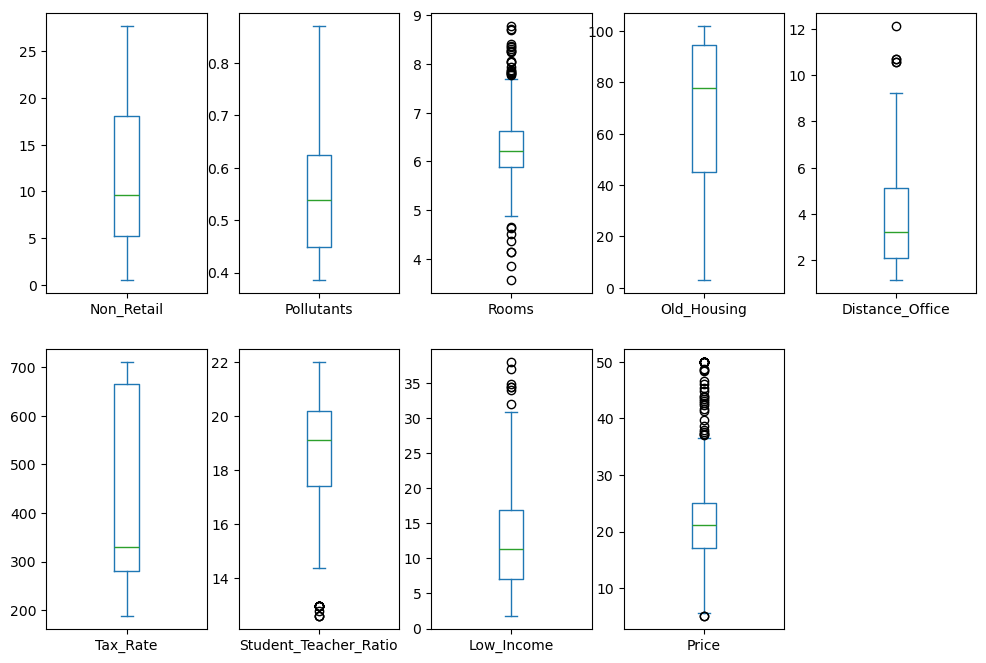

In [67]:

df_numerics = df[["Non_Retail","Pollutants","Rooms","Old_Housing","Distance_Office","Tax_Rate","Student_Teacher_Ratio", "Low_Income", "Price"]]
df_numerics.plot(kind='box',  subplots=True, layout=(2, 5), figsize=(12, 8))
plt.show()

**Non_Retail**: Non-retail land use varies widely across different towns, with a median around 10 and relatively large spread

**Pollutants**: Pollution levels show moderate variation across towns, with most values being concentrated around the median.

**Rooms**: Most houses have about 6 rooms, with some outliers with houses with significantly high or low room counts. 

**Old_Housing**: The proportion of old housing varies greatly across towns, showing that theres a wide distribution.

**Distance_Office**: Distances to employment centres vary moderately, with most towns located within a middle range distance.

**Tax_Rate**: Tax rates show large variation across towns, with some towns having significantly higher rates.

**Student_Teacher_Ratio**: Student teacher ratios are quite concentrated around the median, so we can infer that there are similar ratios across most towns.

**Low_Income**: The proportion of low income residents varies across towns, with some towns having much higher proportions

**Price**: Housing prices show moderate variation, with a few higher valued outliers, which shows that some towns have significantly more expensive houses.

We can see that we have outliers present in Rooms, Distance_Office, Student_Teacher_Ratio, Low_Income and Price.
For each of these columns, we calculate the IQR range and remove data that exceeds the range.

In [68]:
def removeOutliers(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[column_name] >= lower) & (df[column_name] <= upper)]

    return df

df = removeOutliers(df, 'Rooms')
df = removeOutliers(df, 'Distance_Office')
df = removeOutliers(df, 'Student_Teacher_Ratio')
df = removeOutliers(df, 'Low_Income')
df = removeOutliers(df, 'Price')

df.count()

ID                       412
Crime_Rate               412
Residential_Area         412
Non_Retail               412
River                    412
Pollutants               412
Rooms                    412
Old_Housing              412
Distance_Office          412
Highway_Access           412
Tax_Rate                 412
Student_Teacher_Ratio    412
Low_Income               412
Price                    412
dtype: int64

After removal of outliers,

**c.** For categorical variables, perform the necessary encoding.

For all categorical data ("River", "Crime_Rate", "Highway_Access" and "Residential_Area"), we perfromed ordnal encoding to encode them.

In [69]:
# encoding "River" to "0" (Near) and "1" (Far)
encoding = {"Near":0, "Far":1}
df["River_Encoded"] = df["River"].map(encoding)

# encoding "Crime_Rate" and "Highway_Access" to "0" (Low), "1" (Moderate) and "2" (High)
encoding = {"Low": 0, "Moderate":1, "High": 2}
df["Crime_Rate_Encoded"] = df["Crime_Rate"].map(encoding)
df["Highway_Access_Encoded"] = df["Highway_Access"].map(encoding)

# encoding "Residential_Area" to "0" (Very Low), "1" (Low), "2" (Moderate), "3" (High), "4" (Very High)
encoding = {"Very Low": 0, "Low": 1, "Moderate": 2, "High": 3, "Very High": 4}
df["Residential_Area_Encoded"] = df["Residential_Area"].map(encoding)

df

,ID,Crime_Rate,Residential_Area,Non_Retail,River,Pollutants,Rooms,Old_Housing,Distance_Office,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Low_Income,Price,River_Encoded,Crime_Rate_Encoded,Highway_Access_Encoded,Residential_Area_Encoded
0,1,Low,Very Low,2.31,Far,0.538,6.575,65.2,4.0900,Low,296,15.3,4.98,24.0,1,0,0,0
1,2,Low,Very Low,7.07,Far,0.469,6.421,78.9,4.9671,Low,242,17.8,9.14,21.6,1,0,0,0
2,3,Low,Very Low,7.07,Far,0.469,7.185,61.1,4.9671,Low,242,17.8,4.03,34.7,1,0,0,0
3,4,Low,Very Low,2.18,Far,0.458,6.998,45.8,6.0622,Low,222,18.7,2.94,33.4,1,0,0,0
5,6,Low,Very Low,2.18,Far,0.458,6.430,58.7,6.0622,Low,222,18.7,5.21,28.7,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,Low,Very Low,11.93,Far,0.573,6.593,69.1,2.4786,Low,273,21.0,9.67,22.4,1,0,0,0
502,503,Low,Very Low,11.93,Far,0.573,6.120,76.7,2.2875,Low,282,21.0,9.08,20.6,1,0,0,0
503,504,Low,Very Low,11.93,Far,0.573,6.976,91.0,2.1675,Low,273,21.0,5.64,23.9,1,0,0,0
504,505,Low,Very Low,11.93,Far,0.573,6.794,89.3,2.3889,Low,273,21.0,6.48,22.0,1,0,0,0


**Response.** 

### 3.	Exploratory analysis and visualization [50% of Part I]

**a.** For each variable, provide relevant summary statistics

In [70]:
for col in range(14):

    column = df.iloc[:, col]

    print("Variable:", df.columns[col])
    if col == 0:
        print("Type: Categorical")
        print("Unique values:", column.nunique())
        print("\n")
        continue

    if column.dtype != "object":
        print("Type: Numerical")
        print("Count:", column.count())
        print("Mean:", column.mean())
        print("Median:", column.median())
        print("Min:", column.min())
        print("Max:", column.max())
        print("Standard Deviation:", column.std())
    
    else:
        print("Type: Categorical")
        print("Unique values:", column.nunique())
        print("Most frequent values:")
        print(column.value_counts().head(5))

    print("\n")
    

Variable: ID
Type: Categorical
Unique values: 412


Variable: Crime_Rate
Type: Categorical
Unique values: 3
Most frequent values:
Crime_Rate
Low         320
Moderate     85
High          7
Name: count, dtype: int64


Variable: Residential_Area
Type: Categorical
Unique values: 5
Most frequent values:
Residential_Area
Very Low     326
Low           46
Moderate      17
Very High     15
High           8
Name: count, dtype: int64


Variable: Non_Retail
Type: Numerical
Count: 412
Mean: 11.457184466019417
Median: 9.9
Min: 0.74
Max: 27.74
Standard Deviation: 6.614894042766887


Variable: River
Type: Categorical
Unique values: 2
Most frequent values:
River
Far     388
Near     24
Name: count, dtype: int64


Variable: Pollutants
Type: Numerical
Count: 412
Mean: 0.5548218446601941
Median: 0.538
Min: 0.385
Max: 0.871
Standard Deviation: 0.11695803272738463


Variable: Rooms
Type: Numerical
Count: 412
Mean: 6.1966213592233
Median: 6.167999999999999
Min: 4.88
Max: 7.691
Standard Deviation: 0.4724528

**b.** For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

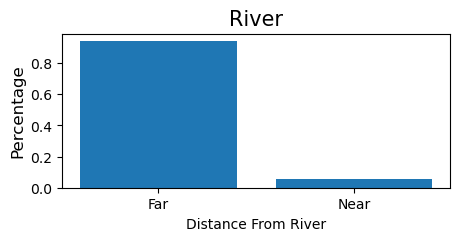

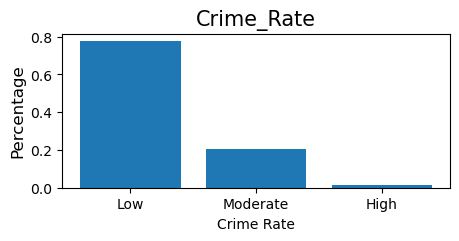

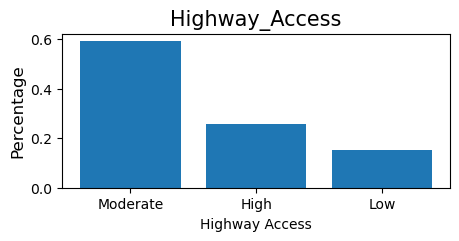

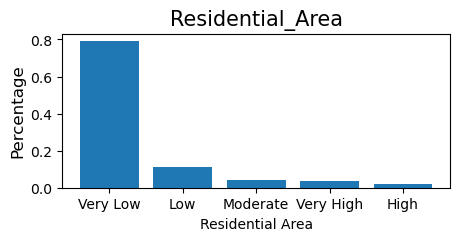

In [71]:
df["River"] = df["River"].astype(str)
data = df["River"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(5,2))
plt.bar(xs, ys)
plt.title("River", fontsize=15)
plt.xlabel("Distance From River")
plt.ylabel("Percentage", fontsize=12)
plt.show()

df["Crime_Rate"] = df["Crime_Rate"].astype(str)
data = df["Crime_Rate"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(5,2))
plt.bar(xs, ys)
plt.title("Crime_Rate", fontsize=15)
plt.xlabel("Crime Rate")
plt.ylabel("Percentage", fontsize=12)
plt.show()

df["Highway_Access"] = df["Highway_Access"].astype(str)
data = df["Highway_Access"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(5,2))
plt.bar(xs, ys)
plt.title("Highway_Access", fontsize=15)
plt.xlabel("Highway Access")
plt.ylabel("Percentage", fontsize=12)
plt.show()

df["Residential_Area"] = df["Residential_Area"].astype(str)    
data = df["Residential_Area"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(5,2))
plt.bar(xs, ys)
plt.title("Residential_Area", fontsize=15)
plt.xlabel("Residential Area")
plt.ylabel("Percentage", fontsize=12)
plt.show()


River

Majority of towns are located far from a river (94.2%)
There is a large imbalance between towns that are located far from a river and towns that are located near a river

Crime_Rate

Majority of towns have a low crime rate (77.7%)
There is a small minority of towns that have a high crime rate (1.70%)

Highway_Access

Most towns have moderate highway access (59.2%)
There is a minority of towns that have a low access to highway(15.0%)


Residential_Area

A large majority towns have a very low percentage of residential area greater than 25000 square feet (79.1%)
There is a large imblance of towns that have a very low residential area greaer than 25000 square feet than those that do not.

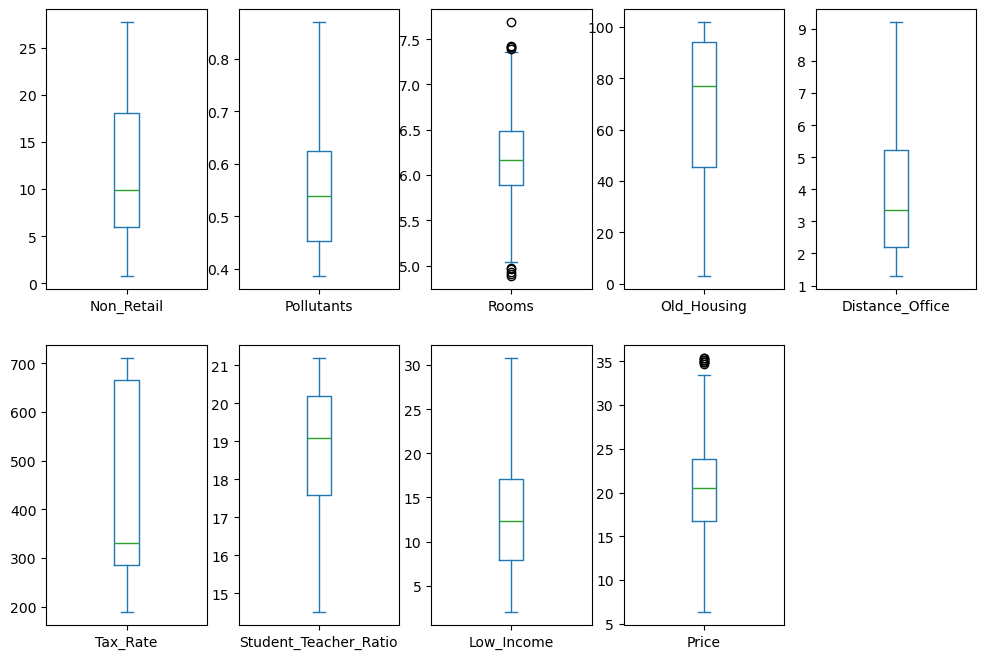

In [72]:
df_numerics = df[["Non_Retail","Pollutants","Rooms","Old_Housing","Distance_Office","Tax_Rate","Student_Teacher_Ratio", "Low_Income", "Price"]]
df_numerics.plot(kind='box',  subplots=True, layout=(2, 5), figsize=(12, 8))
plt.show()

**Response.** 

**c.** Perform bi-variate analysis on the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables. Use appropriate statistical methods and/or visualizations.

Non_Retail


Non-retail land use varies widely across different towns, with a median around 10 and relatively large spread

Pollutants


Pollution levels show moderate variation across towns, with most values being concentrated around the median.

Rooms


Most houses have about 6 rooms, with some outliers with houses with significantly high or low room counts. 

Old_Housing

The proportion of old housing varies greatly across towns, showing that theres a wide distribution.

Distance_Office

Distances to employment centres vary moderately, with most towns located within a middle range distance.

Tax_Rate

Tax rates show large variation across towns, with some towns having significantly higher rates.

Student_Teacher_Ratio

Student teacher ratios are quite concentrated around the median, so we can infer that there are similar ratios across most towns.

Low_Income

The proportion of low income residents varies across towns, with some towns having much higher proportions

Price 

Housing prices show moderate variation, with a few higher valued outliers, which shows that some towns have significantly more expensive houses.

**Response.** 

We use this table to denote the strength of a relationship based on the correlation coefficient.

| r value  | Interpretation         |
| -------- | ---------------------- |
| 0        | No linear relationship |
| ±0.1–0.3 | Weak                   |
| ±0.3–0.5 | Moderate               |
| ±0.5–0.7 | Strong                 |
| ±0.7+    | Very strong            |

### Variables versus Price
First, we analysed the variables that affect the median price of homes (Price).

#### 1. Rooms
From the scatter plot, as the number of rooms increases, the price also increases.
Additionally, the correlation coefficient is 0.689 (3sf), suggesting a strong positive linear relationship.

Logically, this makes sense as houses with more rooms tend to cost more. 

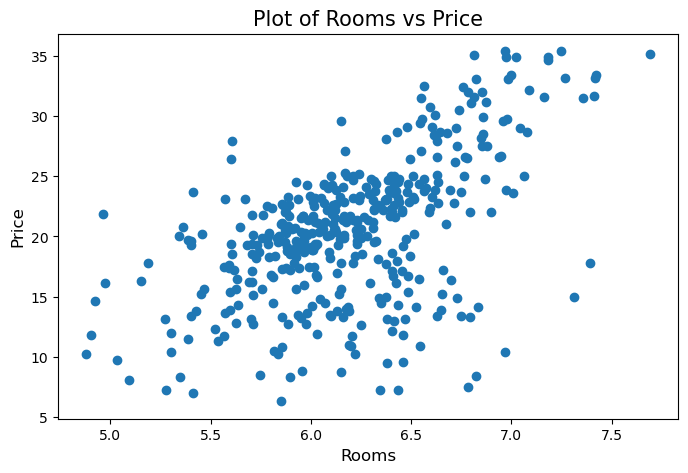

In [73]:
xs = df.Rooms
ys = df.Price

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Rooms vs Price", fontsize=15)
plt.xlabel("Rooms", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [74]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.55679052]
 [0.55679052 1.        ]]


#### 2. Low Income
From the scatter plot, we can see that residential areas with a higher percentage of lower income households tend to have lower-priced housing.

The correlation coefficient is -0.738 (3sf), suggesting a very strong negative linear relationship.

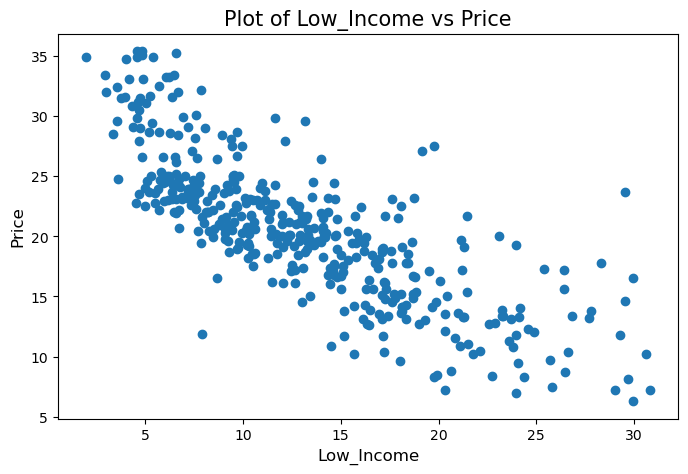

In [75]:
xs = df.Low_Income
ys = df.Price

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Low_Income vs Price", fontsize=15)
plt.xlabel("Low_Income", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [76]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.         -0.78998369]
 [-0.78998369  1.        ]]


#### 3. Crime Rates
From the table, we can see that a higher crime rate leads to a lower mean price of houses. The boxplot also illustrates this.

This shows that crime rate and price have a negative relationship.

In [77]:
df.groupby('Crime_Rate_Encoded')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Crime_Rate_Encoded,,,,,,,,
0,320.0,22.075000,5.254453,7.0,18.975,21.7,24.425,35.4
1,85.0,15.397647,5.118267,6.3,12.000,14.3,19.100,29.8
2,7.0,11.485714,2.472130,8.8,10.400,10.5,12.000,16.3


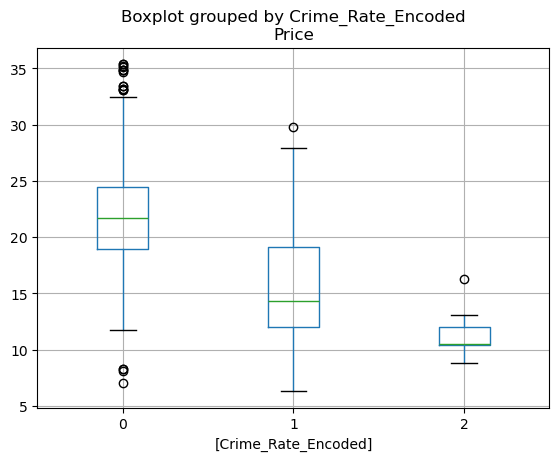

In [78]:
df[['Crime_Rate_Encoded','Price']].boxplot(by='Crime_Rate_Encoded')
plt.show()

#### 4. Pollutants
From the scatter plot, we can see that more polluted residential areas tend to have lower-priced housing.

The correlation coefficient is -0.417 (3sf), suggesting a moderate negative linear relationship.

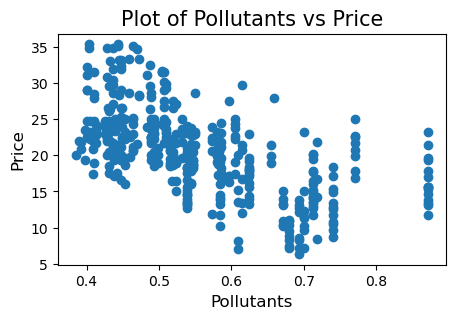

In [79]:
xs = df.Pollutants
ys = df.Price

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Pollutants vs Price", fontsize=15)
plt.xlabel("Pollutants", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [80]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.        -0.5969753]
 [-0.5969753  1.       ]]


### Variables versus Low Income
Secondly, we analysed the variables that correlate with the percentage of low income households in a residential area.

#### 1. Crime Rate
Both the table and the boxplot strongly suggest that Crime_Rate and Low_Income have a positive relationship.

This means that residential areas with a higher percentage of lower income households also tended to have higher crime rates.

In [81]:
df.groupby('Crime_Rate_Encoded')['Low_Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Crime_Rate_Encoded,,,,,,,,
0,320.0,11.408781,5.579558,1.98,7.170,10.28,14.385,29.93
1,85.0,18.581176,5.200402,7.01,15.170,18.13,21.780,30.81
2,7.0,20.695714,4.020261,14.52,18.645,20.62,22.900,26.64


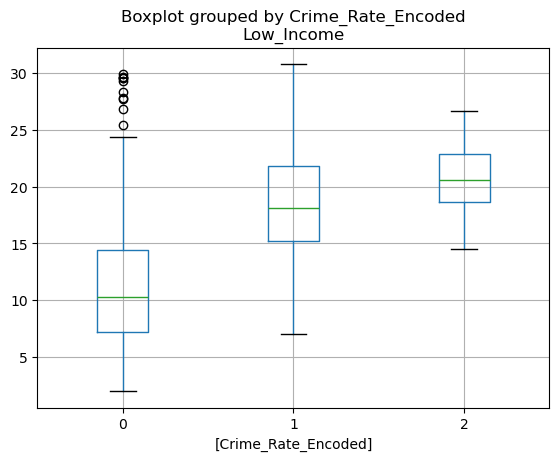

In [82]:
df[['Crime_Rate_Encoded','Low_Income']].boxplot(by='Crime_Rate_Encoded')
plt.show()

#### 2. Pollutants
The scatter plot shows that residential areas with a higher percentage of lower income households also tended to be more polluted.

The correlation coefficient is 0.602 (3sf), suggesting a strong positive linear relationship.

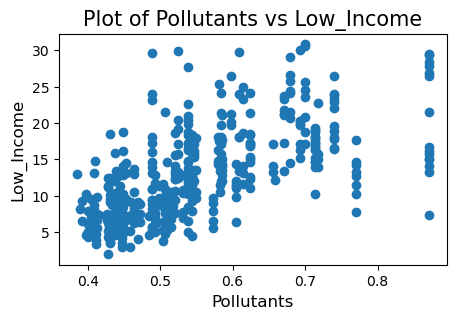

In [83]:
xs = df.Pollutants
ys = df.Low_Income

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Pollutants vs Low_Income", fontsize=15)
plt.xlabel("Pollutants", fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [84]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.63744836]
 [0.63744836 1.        ]]


#### 3. Rooms
The scatter plot shows that as Low_Income increases, Rooms decrease.

The correlation coefficient is -0.607, hence it is a moderate positive relationship.

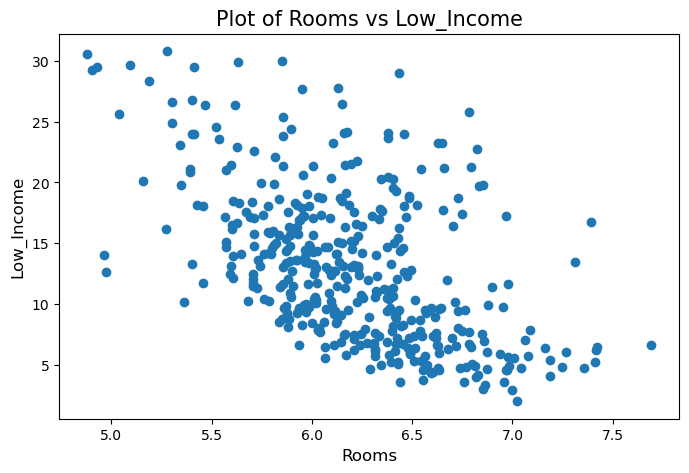

In [85]:
xs = df["Rooms"]
ys = df["Low_Income"]

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Rooms vs Low_Income", fontsize=15)
plt.xlabel("Rooms", fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [86]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.         -0.54536983]
 [-0.54536983  1.        ]]


#### 4. Student_Teacher_Ratio
The scatter plot shows a positive relationship between Low_Income and Student_Teacher_Ratio.

The correlation coefficient is 0.370, hence it is a moderate positive relationship.

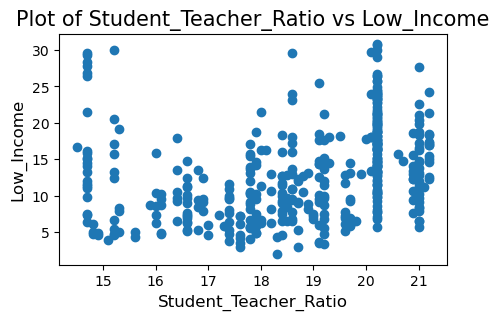

In [87]:
xs = df['Student_Teacher_Ratio']
ys = df.Low_Income

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Student_Teacher_Ratio vs Low_Income", fontsize=15)
plt.xlabel('Student_Teacher_Ratio', fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [88]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.28957484]
 [0.28957484 1.        ]]


### Other Relationships

#### 1. Highway_Access versus Pollutants
Both the table and the boxplot shows that as Highway_Access increases, Pollutants increase.

This is likely because more accessible highways lead to more usage of vehicles, which in turn cause more pollution.

In [89]:
df.groupby('Highway_Access_Encoded')['Pollutants'].describe()

,count,mean,std,min,25%,50%,75%,max
Highway_Access_Encoded,,,,,,,,
0,62.0,0.467852,0.056872,0.385,0.4379,0.449,0.48875,0.581
1,244.0,0.525315,0.107479,0.398,0.4429,0.510,0.54700,0.871
2,106.0,0.673613,0.064776,0.532,0.6140,0.693,0.71300,0.770


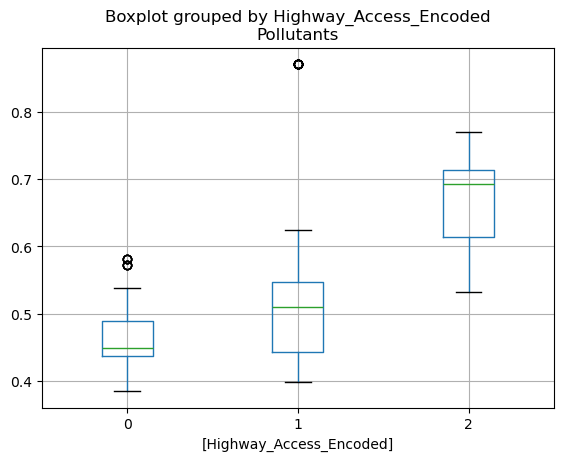

In [90]:
df[['Highway_Access_Encoded','Pollutants']].boxplot(by='Highway_Access_Encoded')
plt.show()